In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Функция для логирования в runs.csv
def log_run(run_data, csv_path='artifacts/runs.csv'):
    df = pd.DataFrame([run_data])
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df = pd.concat([df_existing, df], ignore_index=True)
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    df.to_csv(csv_path, index=False)

# Функция для сохранения лучшей модели
def save_best_model(model, config, path='artifacts/best_classifier.pt', config_path='artifacts/best_classifier_config.json'):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(model.state_dict(), path)
    import json
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)

# Визуализация батча
def show_batch(dataloader, title="Batch Examples"):
    images, labels = next(iter(dataloader))
    images = images[:8]
    labels = labels[:8]
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    for i, (img, lbl) in enumerate(zip(images, labels)):
        img = img.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())  # нормализация для отображения
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {lbl.item()}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Train base batch: torch.Size([64, 3, 32, 32])
Val batch: torch.Size([64, 3, 32, 32])


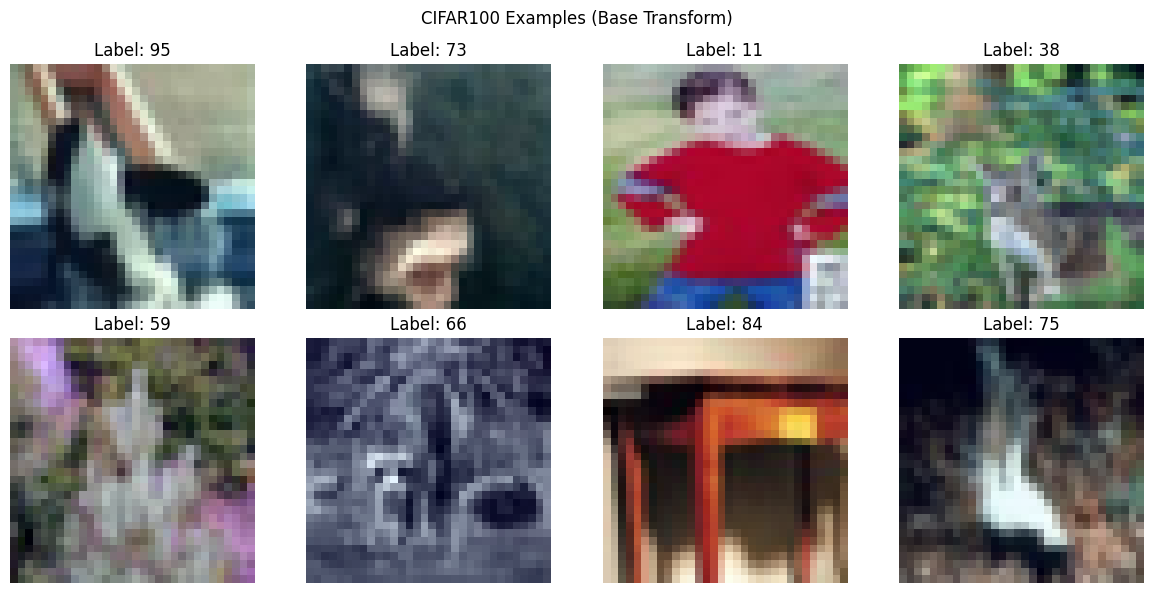

In [6]:
# Определяем transforms
mean = (0.5071, 0.4867, 0.4408)
std = (0.2675, 0.2565, 0.2761)

# Базовый transform (без аугментаций)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Аугментации для C2
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transform для pretrained ResNet18
transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка датасета
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_base)
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Для аугментаций используем отдельный датасет с transform_aug
train_aug_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_aug)
train_aug_subset = Subset(train_aug_dataset, train_subset.indices)

# Тестовый датасет
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_base)

# Создаём DataLoader'ы (batch_size=64)
batch_size = 64
train_loader_base = DataLoader(Subset(train_dataset, train_subset.indices), batch_size=batch_size, shuffle=True, num_workers=2)
train_loader_aug = DataLoader(train_aug_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Для ResNet нужны 224x224 изображения
train_resnet_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_resnet)
train_resnet_subset = Subset(train_resnet_dataset, train_subset.indices)
train_resnet_loader = DataLoader(train_resnet_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_resnet_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_resnet_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Sanity check
print("Train base batch:", next(iter(train_loader_base))[0].shape)
print("Val batch:", next(iter(val_loader))[0].shape)
show_batch(train_loader_base, "CIFAR100 Examples (Base Transform)")

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [9]:
criterion = nn.CrossEntropyLoss()
epochs = 20
best_val_acc = 0.0
best_model_state = None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# C1: simple-cnn-base
model_c1 = SimpleCNN().to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.001)
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_c1, train_loader_base, criterion, optimizer_c1, device)
    val_loss, val_acc = evaluate(model_c1, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"C1 Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c1.state_dict().copy()

# Сохраняем результаты
log_run({
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'base transform'
})

# C2: simple-cnn-aug
model_c2 = SimpleCNN().to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=0.001)
best_val_acc = 0.0
history_c2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_aug, criterion, optimizer_c2, device)
    val_loss, val_acc = evaluate(model_c2, val_loader, criterion, device)
    history_c2['train_loss'].append(train_loss)
    history_c2['train_acc'].append(train_acc)
    history_c2['val_loss'].append(val_loss)
    history_c2['val_acc'].append(val_acc)
    print(f"C2 Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c2.state_dict().copy()

log_run({
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'with augmentations'
})

C1 Epoch 1: train_loss=4.0718, train_acc=0.0706, val_loss=3.7422, val_acc=0.1253
C1 Epoch 2: train_loss=3.5698, train_acc=0.1489, val_loss=3.4405, val_acc=0.1754
C1 Epoch 3: train_loss=3.2808, train_acc=0.2033, val_loss=3.1912, val_acc=0.2267
C1 Epoch 4: train_loss=3.0770, train_acc=0.2427, val_loss=3.0574, val_acc=0.2437
C1 Epoch 5: train_loss=2.9008, train_acc=0.2764, val_loss=2.8877, val_acc=0.2907
C1 Epoch 6: train_loss=2.7549, train_acc=0.3079, val_loss=2.7513, val_acc=0.3128
C1 Epoch 7: train_loss=2.6475, train_acc=0.3272, val_loss=2.6940, val_acc=0.3285
C1 Epoch 8: train_loss=2.5499, train_acc=0.3494, val_loss=2.6658, val_acc=0.3238
C1 Epoch 9: train_loss=2.4718, train_acc=0.3656, val_loss=2.5720, val_acc=0.3456
C1 Epoch 10: train_loss=2.4066, train_acc=0.3755, val_loss=2.5243, val_acc=0.3580
C1 Epoch 11: train_loss=2.3377, train_acc=0.3922, val_loss=2.5118, val_acc=0.3577
C1 Epoch 12: train_loss=2.2840, train_acc=0.4045, val_loss=2.4674, val_acc=0.3747
C1 Epoch 13: train_loss=2

In [ ]:
# C3: resnet18-head-only
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from tqdm import tqdm

def train_one_epoch_add(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in tqdm(loader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

model_c3 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_c3.parameters():
    param.requires_grad = False
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 100)
model_c3 = model_c3.to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=0.001)

best_val_acc = 0.0
history_c3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch_add(model_c3, train_resnet_loader, criterion, optimizer_c3, device)
    val_loss, val_acc = evaluate(model_c3, val_resnet_loader, criterion, device)
    history_c3['train_loss'].append(train_loss)
    history_c3['train_acc'].append(train_acc)
    history_c3['val_loss'].append(val_loss)
    history_c3['val_acc'].append(val_acc)
    print(f"C3 Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c3.state_dict().copy()

log_run({
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'ResNet18 (pretrained, head only)',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'backbone frozen'
})

# C4: resnet18-finetune (разморозим layer4 и fc)
model_c4 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, 100)
model_c4.fc.requires_grad = True
model_c4 = model_c4.to(device)
optimizer_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=0.001)

best_val_acc = 0.0
history_c4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch_add(model_c4, train_resnet_loader, criterion, optimizer_c4, device)
    val_loss, val_acc = evaluate(model_c4, val_resnet_loader, criterion, device)
    history_c4['train_loss'].append(train_loss)
    history_c4['train_acc'].append(train_acc)
    history_c4['val_loss'].append(val_loss)
    history_c4['val_acc'].append(val_acc)
    print(f"C4 Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c4.state_dict().copy()

log_run({
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'ResNet18 (pretrained, finetune layer4+fc)',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'layer4+fc unfrozen'
})

# Выбираем лучшую модель по best_val_accuracy из runs.csv
# В данном примере сохраним последнюю лучшую (C4)
save_best_model(model_c4, {
    'dataset': 'CIFAR100',
    'architecture': 'ResNet18',
    'transforms': 'resize224+normalize_imagenet',
    'hyperparams': {'lr': 0.001, 'optimizer': 'Adam', 'epochs': epochs, 'batch_size': batch_size},
    'seed': 42
})

Training:   2%|▏         | 13/625 [00:19<12:44,  1.25s/it]

In [ ]:
# Построим кривые обучения для лучшего прогона (C4)
os.makedirs('artifacts/figures', exist_ok=True)
epochs_range = range(1, epochs+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, history_c4['train_loss'], label='Train Loss')
plt.plot(epochs_range, history_c4['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs_range, history_c4['train_acc'], label='Train Acc')
plt.plot(epochs_range, history_c4['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.suptitle('C4: ResNet18 Finetune')
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

# Сравнение лучших val_accuracy по C1-C4
exp_ids = ['C1', 'C2', 'C3', 'C4']
best_vals = []
for exp in exp_ids:
    df = pd.read_csv('artifacts/runs.csv')
    best_val = df[df['experiment_id']==exp]['best_val_accuracy'].iloc[-1]
    best_vals.append(best_val)

plt.figure(figsize=(8,5))
plt.bar(exp_ids, best_vals)
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison C1-C4')
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

# Визуализация аугментаций
train_aug_dataset = datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_aug)
fig, axes = plt.subplots(2, 5, figsize=(15,6))
for i, ax in enumerate(axes.flatten()):
    img, _ = train_aug_dataset[i]
    img = img.permute(1,2,0).numpy()
    img = (img * std) + mean  # денормализация
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Augmented Examples')
plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()

In [ ]:
# Для детекции используем предобученную Faster R-CNN
# Загрузка датасета VOC Detection
voc_train = datasets.VOCDetection(root='./data', year='2012', image_set='train', download=True)
voc_val = datasets.VOCDetection(root='./data', year='2012', image_set='val', download=True)

# Определим transform для модели: Resize и нормализация
def transform_detection(image, target):
    # target – это dict с 'annotation' от VOC
    # Для модели из torchvision ожидается список dict'ов с полями 'boxes', 'labels'
    # Преобразуем XML в нужный формат
    boxes = []
    labels = []
    for obj in target['annotation']['object']:
        bbox = obj['bndbox']
        boxes.append([float(bbox['xmin']), float(bbox['ymin']), float(bbox['xmax']), float(bbox['ymax'])])
        labels.append(1)  # в VOC все объекты, но для упрощения используем класс 1 (можно расширить)
    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    labels = torch.as_tensor(labels, dtype=torch.int64)
    target = {'boxes': boxes, 'labels': labels}
    # Преобразование изображения
    image = F.to_tensor(image)
    image = F.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    return image, target

class VOCDetectionWrapper(torch.utils.data.Dataset):
    def __init__(self, voc_dataset):
        self.voc = voc_dataset
    def __len__(self):
        return len(self.voc)
    def __getitem__(self, idx):
        img, target = self.voc[idx]
        img, target = transform_detection(img, target)
        return img, target

train_det = VOCDetectionWrapper(voc_train)
val_det = VOCDetectionWrapper(voc_val)
train_loader_det = DataLoader(train_det, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader_det = DataLoader(val_det, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# Sanity check
images, targets = next(iter(train_loader_det))
print("Batch of images shape:", images[0].shape)
print("Targets:", targets[0])

In [ ]:
model_det = fasterrcnn_resnet50_fpn(pretrained=True)
model_det.to(device)
model_det.eval()

def compute_iou(box1, box2):
    # box: [x1, y1, x2, y2]
    inter_x1 = max(box1[0], box2[0])
    inter_y1 = max(box1[1], box2[1])
    inter_x2 = min(box1[2], box2[2])
    inter_y2 = min(box1[3], box2[3])
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0

def evaluate_detection(model, loader, score_threshold=0.5, iou_threshold=0.5, device='cpu'):
    model.eval()
    all_pred_boxes = []
    all_gt_boxes = []
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)
            for i, output in enumerate(outputs):
                pred_boxes = output['boxes'][output['scores'] > score_threshold].cpu().numpy()
                pred_scores = output['scores'][output['scores'] > score_threshold].cpu().numpy()
                gt_boxes = targets[i]['boxes'].cpu().numpy()
                # Сопоставление
                tp = 0
                fp = 0
                matched_gt = set()
                for pbox in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1
                    for j, gbox in enumerate(gt_boxes):
                        iou = compute_iou(pbox, gbox)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = j
                    if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
                        tp += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp += 1
                fn = len(gt_boxes) - len(matched_gt)
                precision = tp / (tp + fp) if tp+fp>0 else 0
                recall = tp / (tp + fn) if tp+fn>0 else 0
                # mean IoU по сопоставленным
                ious = []
                for j, gbox in enumerate(gt_boxes):
                    if j in matched_gt:
                        # найти соответствующий pred box
                        for pbox in pred_boxes:
                            iou = compute_iou(pbox, gbox)
                            if iou >= iou_threshold:
                                ious.append(iou)
                                break
                mean_iou = np.mean(ious) if ious else 0
                all_pred_boxes.append((pred_boxes, pred_scores))
                all_gt_boxes.append(gt_boxes)
    # Суммарные метрики по всем изображениям (усреднение)
    # Для простоты возвращаем средние
    return precision, recall, mean_iou

# Прогон для V1 (score_threshold=0.3) и V2 (0.7)
thresholds = [0.3, 0.7]
results = []
for thresh in thresholds:
    p, r, miou = evaluate_detection(model_det, val_loader_det, score_threshold=thresh, device=device)
    results.append((thresh, p, r, miou))
    log_run({
        'experiment_id': f'V{1 if thresh==0.3 else 2}',
        'task': 'detection',
        'dataset': 'VOC2012',
        'seed': 42,
        'model_summary': 'FasterRCNN_ResNet50_FPN',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': p,
        'recall': r,
        'mean_iou': miou,
        'notes': f'score_threshold={thresh}'
    })
print(results)

In [ ]:
def visualize_predictions(model, loader, score_threshold=0.3, num_samples=4, device='cpu'):
    model.eval()
    images, targets = next(iter(loader))
    images = [img.to(device) for img in images]
    outputs = model(images)
    fig, axes = plt.subplots(2, num_samples//2, figsize=(15,8))
    axes = axes.flatten()
    for i in range(num_samples):
        img = images[i].cpu().permute(1,2,0).numpy()
        # Денормализация
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].axis('off')
        # GT boxes
        gt_boxes = targets[i]['boxes'].cpu().numpy()
        for box in gt_boxes:
            rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 fill=False, edgecolor='green', linewidth=2)
            axes[i].add_patch(rect)
        # Pred boxes
        pred = outputs[i]
        keep = pred['scores'] > score_threshold
        pred_boxes = pred['boxes'][keep].cpu().numpy()
        pred_scores = pred['scores'][keep].cpu().numpy()
        for box, score in zip(pred_boxes, pred_scores):
            rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 fill=False, edgecolor='red', linewidth=2)
            axes[i].add_patch(rect)
            axes[i].text(box[0], box[1], f'{score:.2f}', color='red', fontsize=8)
        axes[i].set_title(f"GT: green, Pred: red (th={score_threshold})")
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/detection_examples_th{score_threshold}.png')
    plt.show()

visualize_predictions(model_det, val_loader_det, score_threshold=0.3, num_samples=4, device=device)
visualize_predictions(model_det, val_loader_det, score_threshold=0.7, num_samples=4, device=device)

In [ ]:
# Простой bar chart для сравнения precision/recall при разных порогах
df_det = pd.read_csv('artifacts/runs.csv')
df_det = df_det[df_det['task']=='detection']
thresholds = df_det['experiment_id'].tolist()
prec = df_det['precision'].tolist()
rec = df_det['recall'].tolist()
miou = df_det['mean_iou'].tolist()

x = np.arange(len(thresholds))
width = 0.25
fig, ax = plt.subplots()
ax.bar(x - width, prec, width, label='Precision')
ax.bar(x, rec, width, label='Recall')
ax.bar(x + width, miou, width, label='Mean IoU')
ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_ylabel('Score')
ax.set_title('Detection Metrics vs Score Threshold')
ax.legend()
plt.savefig('artifacts/figures/detection_metrics.png')
plt.show()